In [19]:
import json
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import os
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 13

In [20]:
genes = ["HA", "NA", "PB1"]
clades = ["na_avian", "eurasian_avian", "canine_h3n2",  "equine", "human", "swine_NA", "swine_euro"]

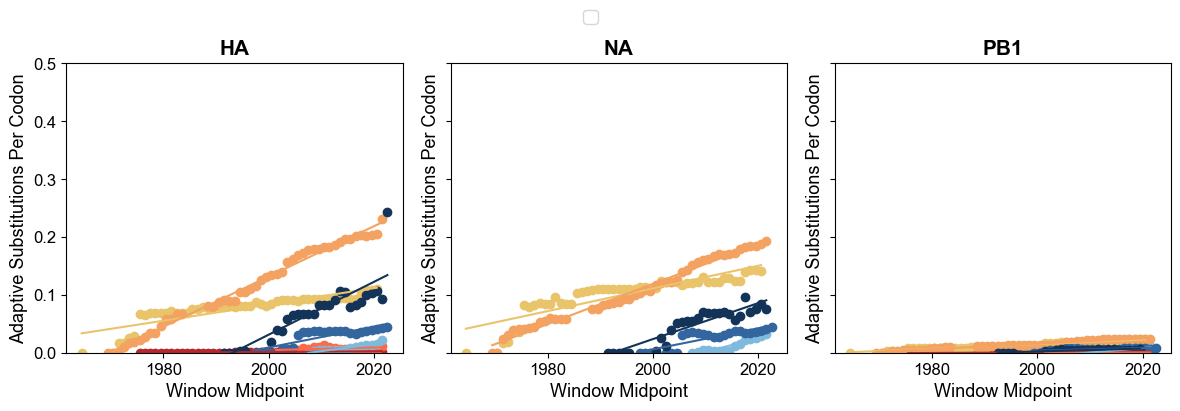

In [21]:
clade_colors = {
    'na_avian': '#b6282e',
    'eurasian_avian': '#fb6a4a',
    'swine_euro': "#133359",
    'swine_NA': '#33659e',
    'canine_h3n2': '#7fbadc',
    'human': '#f4a261',
    'equine': '#e9c46a'
}

legend_handles = {}

num_genes = len(genes)
num_columns = 3
num_rows = (num_genes + num_columns - 1) // num_columns

fig, axs = plt.subplots(num_rows, num_columns, sharex=True, sharey=True, figsize=(12, 4 * num_rows), label='')
fig.legend(clades, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(clades), fontsize=13)
axs = axs.flatten()

for clade_index, clade in enumerate(clades):
    clade_color = clade_colors.get(clade, 'black')

    for i, gene in enumerate(genes):
        path = f"./{clade}/{gene}_3_3_adaptation_bootstrapped.json"
        if os.path.exists(path):
            with open(path, "r") as file:
                jsonData = json.load(file)

            x = jsonData['window_midpoint']
            y = jsonData['adaptive_substitutions_per_codon']

            axs[i].scatter(x, y, label=clade, color=clade_color)

            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            axs[i].plot(x, slope * np.array(x) + intercept, color=clade_color)

            axs[i].set_title(f"{gene}", fontsize=15, fontweight='bold')
            axs[i].set_ylabel("Adaptive Substitutions Per Codon", fontsize=13)
            axs[i].set_xlabel("Window Midpoint", fontsize=13)
            axs[i].tick_params(axis='both', labelsize=12)
            axs[i].set_ylim(0, 0.50)


plt.tight_layout()
plt.show()

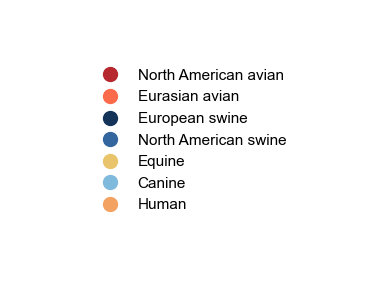

In [24]:
import matplotlib.lines as mlines

clade_colors = {
    'na_avian': '#b6282e',
    'eurasian_avian': '#fb6a4a',
    'swine_euro': "#133359",
    'swine_NA': '#33659e',
    'canine_h3n2': '#7fbadc',
    'human': '#f4a261',
    'equine': '#e9c46a'
}

custom_labels = [
    'North American avian',
    'Eurasian avian',
    'European swine',
    'North American swine',
    'Equine',
    'Canine',
    'Human'
]

clade_keys = ['na_avian', 'eurasian_avian', 'swine_euro', 'swine_NA', 'equine', 'canine_h3n2', 'human']

handles = [
    mlines.Line2D([], [], color=clade_colors[key], marker='o', linestyle='None', markersize=10)
    for key in clade_keys
]

fig_legend, ax_legend = plt.subplots(figsize=(4, 3))
ax_legend.legend(handles, custom_labels, loc='center', fontsize=11, frameon=False)
ax_legend.axis('off')
plt.tight_layout()
plt.show()

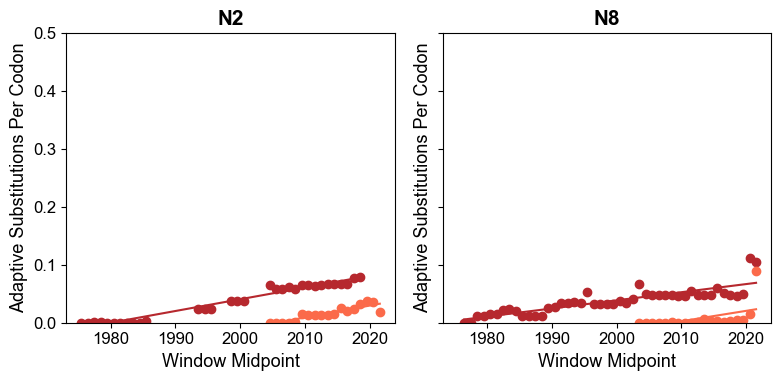

In [25]:
na_genes = ['N2', 'N8']
na_clades = ['na_avian', 'eurasian_avian']

fig_na, axs_na = plt.subplots(1, len(na_genes), sharex=True, sharey=True, figsize=(8, 4))

for i, gene in enumerate(na_genes):
    for clade in na_clades:
        clade_color = clade_colors.get(clade, 'black')
        path = f"./{clade}/{gene}_3_3_adaptation_bootstrapped.json"
        if os.path.exists(path):
            with open(path, "r") as file:
                jsonData = json.load(file)

            x = jsonData['window_midpoint']
            y = jsonData['adaptive_substitutions_per_codon']

            axs_na[i].scatter(x, y, label=clade, color=clade_color)

            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            axs_na[i].plot(x, slope * np.array(x) + intercept, color=clade_color)

        axs_na[i].set_title(gene, fontsize=15, fontweight='bold')
        axs_na[i].set_ylabel("Adaptive Substitutions Per Codon", fontsize=13)
        axs_na[i].set_xlabel("Window Midpoint", fontsize=13)
        axs_na[i].tick_params(axis='both', labelsize=12)
        axs_na[i].set_ylim(0, 0.50)

plt.tight_layout()
plt.show()